<a href="https://colab.research.google.com/github/AquilaITOH/MedicalDataScience-exercises/blob/main/26_Medical_DataScience_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# メディカルデータサイエンス #7 畳み込みニューラルネットワーク (CNN) の医用画像への応用

## 第6回"畳み込みニューラルネットワーク (Convolutional Neural Networks: cNN)" との比較

### MNIST data setのクラス分類タスクの特徴

手書き文字認識ではラベルの付けられた手書き文字データセット MNIST data setを使った。

文字は28x28pxの画像で、70,000サンプル。

教師あり学習に用いる**データの数が十分にある**。

### 医療画像のクラス分類タスクの特徴

今回はLakhaniらによる医用画像Deep learningのチュートリアルを使用する。

画像データは299x299pxの胸部画像または腹部画像でラベルが付けられている。トレーニングデータ65, テストデータは10

**データの数は少ない**。データ数の少なさを補うために、転移学習とデータ拡張を行う。

> Lakhani, P., Gray, D. L., Pett, C. R., Nagy, P. & Shih, G. Hello World Deep Learning in Medical Imaging. J Digit Imaging 31, 2018; 283-289, doi: 10.1007/s10278-018-0079-6

[Hello World Deep Learning in Medical Imaging](https://link.springer.com/article/10.1007/s10278-018-0079-6)

---
## 【26追加機能】1-hot形式出力とGrad-CAMについて

### 1-hot形式（one-hot encoding）

MNISTの実習で学んだ1-hot形式をこのノートブックでも使用する。

| 出力モード | ラベル表現 | 出力層 | 損失関数 |
|---|---|---|---|
| **binary（従来）** | 0 または 1 のスカラー値 | sigmoid（ノード数=1） | binary_crossentropy |
| **1-hot（新）** | [1,0] または [0,1] のベクトル | softmax（ノード数=クラス数） | categorical_crossentropy |

本実習では胸部・腹部の2クラス分類であるため：
- 胸部（Chest） → `[1, 0]`
- 腹部（Abd）   → `[0, 1]`

MNISTでは10クラスで `[0,0,0,1,0,0,0,0,0,0]`（=3）のような形だったが、考え方は同じ。

### Grad-CAM（Gradient-weighted Class Activation Mapping）

CNNが「画像のどの領域に注目して予測したか」をヒートマップとして可視化する手法。

予測根拠を可視化することで、モデルの信頼性評価や医学的妥当性の検証に活用できる。

---

## データ拡張
医用画像は十分な数のトレーニングデータを確保できない場合が多い。

このため、少ない学習データを**水増し**する。

- Original: そのまま
- Translation: ずらす
- Rotation: 回転させる
- Horizontal Flip: 左右反転
- Shear: 斜めに歪める

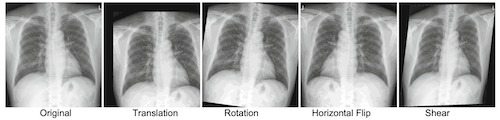

# データ分析の準備

### データのコピー

自分のGoogle Driveを開き、マイドライブの下に「Colab_mnt」の名前でフォルダを作成してください。

[Google Drive](https://drive.google.com/drive/u/0/my-drive)

Teamsで配布したColab_mnt.zipをPCで解凍し、Google DriveのColab_mnt以下にアップロードしてください。

In [ ]:
# ランタイムの構成表示
!nvidia-smi

## ライブラリ・モジュールの読み込み

ライブラリを読み込む。notebook内で1回読み込めば良い。

In [ ]:
import tensorflow as tf
from tensorflow.keras import applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from tensorflow.keras.preprocessing import image
import os
import cv2  # Grad-CAMのヒートマップ重ね合わせに使用

print('TensorFlow version:', tf.__version__)

## 日本語フォントの設定

ローカル環境で確認したパスはColab実環境と異なるため、パスに依存せず自分でフォントをダウンロード・配置する方法です。
Google Fontsから Noto Sans JP を直接取得

In [ ]:
import matplotlib.font_manager as fm
import urllib.request
import os

# Google FontsからNoto Sans JPをダウンロード
font_url = "https://github.com/notofonts/noto-cjk/raw/main/Sans/SubsetOTF/JP/NotoSansJP-Regular.otf"
font_path = "/tmp/NotoSansJP-Regular.otf"

if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

# 登録
fm.fontManager.addfont(font_path)
fp = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fp.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 確認
print("使用フォント:", fp.get_name())

fig, ax = plt.subplots()
ax.set_title("日本語タイトル")
ax.set_xlabel("X軸")
ax.set_ylabel("Y軸")
ax.plot([1,2,3],[4,5,6])
plt.show()

## Google Driveの接続

Google driveを接続する。[Google ドライブに接続]→ ユーザー認証→ driveへのアクセスリクエストを[許可]

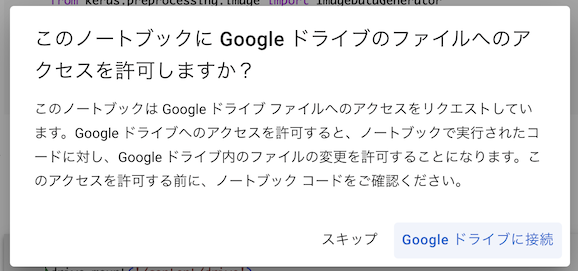

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## 出力形式の選択：binary か 1-hot か

下のセルの `USE_ONEHOT` を変更することで、出力形式を切り替えることができる。

| `USE_ONEHOT` | 出力形式 | 出力層 | クラスラベル |
|---|---|---|---|
| `False` | binary（スカラー） | sigmoid × 1ノード | 0=chest, 1=abd |
| `True` | 1-hot（ベクトル） | softmax × 2ノード | [1,0]=chest, [0,1]=abd |

In [ ]:
# ============================================================
#  出力形式の切り替えスイッチ
#  True  → 1-hot形式（MNISTと同じ形式）
#  False → binary形式（元のチュートリアルと同じ形式）
# ============================================================
USE_ONEHOT = True

# クラス名（フォルダ名と対応）
CLASS_NAMES = ['abd', 'chest']   # アルファベット順 ※ImageDataGeneratorの自動ソート順に合わせる
NUM_CLASSES = len(CLASS_NAMES)

if USE_ONEHOT:
    class_mode = 'categorical'   # 1-hot形式
    output_activation = 'softmax'
    loss_function = 'categorical_crossentropy'
    output_nodes = NUM_CLASSES   # 2ノード
    print(f'出力形式: 1-hot形式 (softmax, {NUM_CLASSES}クラス)')
    print(f'  胸部(chest) → {[1 if c=="chest" else 0 for c in CLASS_NAMES]}')
    print(f'  腹部(abd)   → {[1 if c=="abd" else 0 for c in CLASS_NAMES]}')
else:
    class_mode = 'binary'        # binary形式
    output_activation = 'sigmoid'
    loss_function = 'binary_crossentropy'
    output_nodes = 1             # 1ノード
    print('出力形式: binary形式 (sigmoid, スカラー出力)')
    print('  胸部(chest) → 0, 腹部(abd) → 1')

## 画像のサイズ、データフォルダのpathを設定

In [ ]:
# dimensions of our images.
img_width, img_height = 299, 299

# データセットのパス
base_path = '/content/drive/MyDrive/Colab_mnt'  # 基本となるディレクトリのパス
target_train = 'TRAIN'
target_val   = 'VAL'

full_train_path = os.path.join(base_path, target_train)
full_val_path   = os.path.join(base_path, target_val)

train_data_dir      = full_train_path
validation_data_dir = full_val_path

# モデルのダウンロードと構築
## ハイパーパラメータとデータジェネレータの設定

### データの分割

トレーニングデータとテストデータに分割する。(いつもと同じ)

In [ ]:
# トレーニングと検証のサンプル数
nb_train_samples      = 65
nb_validation_samples = 10

# ハイパーパラメータ
epochs     = 20   # default 20
batch_size = 5

# ---- データ拡張あり ----
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

# ---- データ拡張なし ----
train_datagen_non_augmentation = ImageDataGenerator(
    rescale=1./255)

# ---- テスト用（正規化のみ） ----
test_datagen = ImageDataGenerator(
    rescale=1./255)

# ---- ジェネレータ作成 ----
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode=class_mode)   # USE_ONEHOTに応じて切り替え

train_generator_non_augmentation = train_datagen_non_augmentation.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode=class_mode)

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode=class_mode)

# クラスインデックスの確認（重要: ラベルの対応を確認する）
print('クラスインデックス:', train_generator.class_indices)
print('  ※ このインデックス順に1-hotが割り当てられる')

## ニューラルネットワークのベースモデルの取得

### InceptionNetwork(GoogleLaNet)
Googleの研究チームがが2015年に発表したCNNのアーキテクチャである。
[Szegedy C, Liu W, Jia Y et al. Going deeper with convolutions. In CVPR 2015](https://arxiv.org/abs/1409.4842)

本実習ではImageNetでトレーニングされたInecption V3をベースモデルに使用する。

>Inception v3 は、画像認識モデルで、ImageNet データセットで 78.1% を超える精度を達成することがわかっています。このモデルは、長年にわたって複数の研究者によって開発された多くのアイデアが結実したものです。これは、Szegedy 氏他の『Rethinking the Inception Architecture for Computer Vision』という論文をベースにしています。

>このモデル自体は、畳み込み層、平均プーリング層、最大プーリング層、連結層、ドロップアウト層、全結合層など、対称と非対称の構成要素で構成されています。バッチ正規化はモデル全体で広く使用され、活性化入力に適用されます。損失は Softmax を使用して計算されます。

下記は、モデルの概要図である。

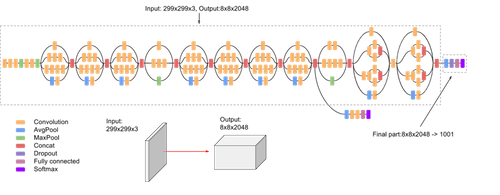

[Inception v3 詳細ガイド](https://cloud.google.com/tpu/docs/inception-v3-advanced?hl=ja)

## トレーニング済み Inception V3

ImageNetを用いてトレーニング済みである。

> ImageNetは、物体認識ソフトウェアの研究で用いるために設計された大規模な画像データベースである。ImageNetでは、1400万を超える画像に手作業でアノテーションを行い、画像にどのような物体が写っているかを示している。

[ImageNet - Wikipedia](https://ja.wikipedia.org/wiki/ImageNet)

In [ ]:
# InceptionV3モデルをベースとして使用
# ImageNetの事前学習済み重みを使用。include_top=FalseでImageNet用の全結合層を除去
base_model = applications.InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(img_width, img_height, 3))

## ニューラルネットワークの作成

### 出力層の比較

```
【binary形式】                    【1-hot形式】
GlobalAveragePooling2D            GlobalAveragePooling2D
       ↓                                 ↓
Dense(1024, relu)                 Dense(1024, relu)
       ↓                                 ↓
Dense(1, sigmoid)                 Dense(2, softmax)
       ↓                                 ↓
  スカラー値                        [p_abd, p_chest]
  0.1 → Chest                     [0.9, 0.1] → abd
  0.9 → Abd                       [0.1, 0.9] → chest
```

In [ ]:
# 新しい全結合層を追加
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)

# 出力層: USE_ONEHOTに応じてノード数と活性化関数を切り替え
# binary  → Dense(1,  activation='sigmoid')
# 1-hot   → Dense(2,  activation='softmax')
predictions = Dense(output_nodes, activation=output_activation)(x)

# モデルの定義
model = Model(inputs=base_model.input, outputs=predictions)

# InceptionV3の層を凍結（転移学習）
for layer in base_model.layers:
    layer.trainable = False

# モデルのコンパイル
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=loss_function,
    metrics=['accuracy'])

print(f'出力層: Dense({output_nodes}, activation="{output_activation}")')
print(f'損失関数: {loss_function}')

## 作成したモデルの確認

In [ ]:
print(model.summary())

## フローチャート形式

フローチャート形式で表示したい。

複雑すぎて可視化できない。

∵inceptionモジュールを多数重ねるアーキテクチャのため

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    show_shapes=True,
)

## 学習（データ拡張あり）

転移学習を行う

転移学習とは、ある領域の知識を別の領域の学習に適用させる技術である。今回の場合、カラー画像(RGB)のクラス分類タスク(ImageNet)で訓練して獲得した知識を、単純Xpの分類タスクの学習に適用する。

In [ ]:
# モデルの学習を実行（データ拡張あり）
history = model.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size)

### 学習過程の表示

In [ ]:
print(history.history.keys())

plt.figure()
plt.plot(history.history['accuracy'],     'orange', label='Training accuracy')
plt.plot(history.history['val_accuracy'], 'blue',   label='Validation accuracy')
plt.plot(history.history['loss'],         'red',    label='Training loss')
plt.plot(history.history['val_loss'],     'green',  label='Validation loss')
plt.legend()
plt.show()

---
## 評価：テストデータによる精度評価（1-hot形式対応）

### 1-hot形式での予測結果の読み方

モデルの出力は各クラスへの「確信度（確率）」のベクトルになる。

```
model.predict(x) → [[0.95, 0.05]]
                         ↑      ↑
                       abd   chest
  → abd の確率: 95%, chest の確率: 5%  → 腹部と予測
```

`np.argmax()` で最大値のインデックスを取得し、クラス名と対応させる。

In [ ]:
# テスト画像のパス設定
full_test_path = os.path.join(base_path, 'TEST')

file_chest = 'chest2.png'
file_abd   = 'abd2.png'

img_path  = os.path.join(full_test_path, file_chest)
img_path2 = os.path.join(full_test_path, file_abd)

def predict_and_display(img_path, model, class_indices, use_onehot=True):
    """
    画像を読み込み、予測結果を表示する関数
    use_onehot=True  → softmax出力を1-hot形式で表示
    use_onehot=False → sigmoid出力をスカラーで表示
    """
    # クラスインデックスの逆引き辞書 {0: 'abd', 1: 'chest'}
    idx_to_class = {v: k for k, v in class_indices.items()}

    img = image.load_img(img_path, target_size=(img_width, img_height))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    img_array = image.img_to_array(img)
    x = np.expand_dims(img_array, axis=0) * 1./255
    score = model.predict(x)

    if use_onehot:
        # 1-hot形式：各クラスの確率を表示
        print('予測スコア（各クラスの確率）:')
        for i, class_name in idx_to_class.items():
            print(f'  {class_name}: {score[0][i]:.4f} ({score[0][i]*100:.1f}%)')

        # 1-hot形式での表示（MNISTと同様）
        onehot_pred = np.zeros(len(idx_to_class), dtype=int)
        onehot_pred[np.argmax(score[0])] = 1
        print(f'1-hot予測ベクトル: {onehot_pred.tolist()}')
        print(f'  ↑ インデックス順: {[idx_to_class[i] for i in range(len(idx_to_class))]}')

        predicted_class = idx_to_class[np.argmax(score[0])]
        print(f'\n→ 予測結果: {predicted_class.upper()} X-ray')
    else:
        # binary形式（従来）
        print(f'予測スコア（sigmoid出力）: {score}')
        predicted_class = 'Chest X-ray' if score[0][0] < 0.5 else 'Abd X-ray'
        print(f'→ 予測結果: {predicted_class}')

    return score, x

# 胸部X線写真の予測
print('=' * 50)
print('【胸部X線写真の予測】')
score_chest, x_chest = predict_and_display(img_path, model, train_generator.class_indices, USE_ONEHOT)

# 腹部X線写真の予測
print('=' * 50)
print('【腹部X線写真の予測】')
score_abd, x_abd = predict_and_display(img_path2, model, train_generator.class_indices, USE_ONEHOT)

---
## Grad-CAM（Gradient-weighted Class Activation Mapping）

### 概要

Grad-CAMは「CNNが予測に際して画像のどの領域を重視したか」をヒートマップで可視化する手法（Selvaraju et al., 2017 doi: 10.1109/ICCV.2017.74.）。

**アルゴリズムの流れ：**
1. 予測したいクラスのスコアを、最後の畳み込み層の出力（特徴マップ）で微分する
2. 各特徴マップに対する勾配の平均を「重み」として計算する
3. 重みと特徴マップの加重和を取り、ReLUを適用してヒートマップを得る
4. 元の画像サイズにリサイズして重ね合わせる

医療AI研究では、モデルが**解剖学的に妥当な領域**に注目しているかを確認するために広く使われる。

#### Grad-CAMのアウトライン

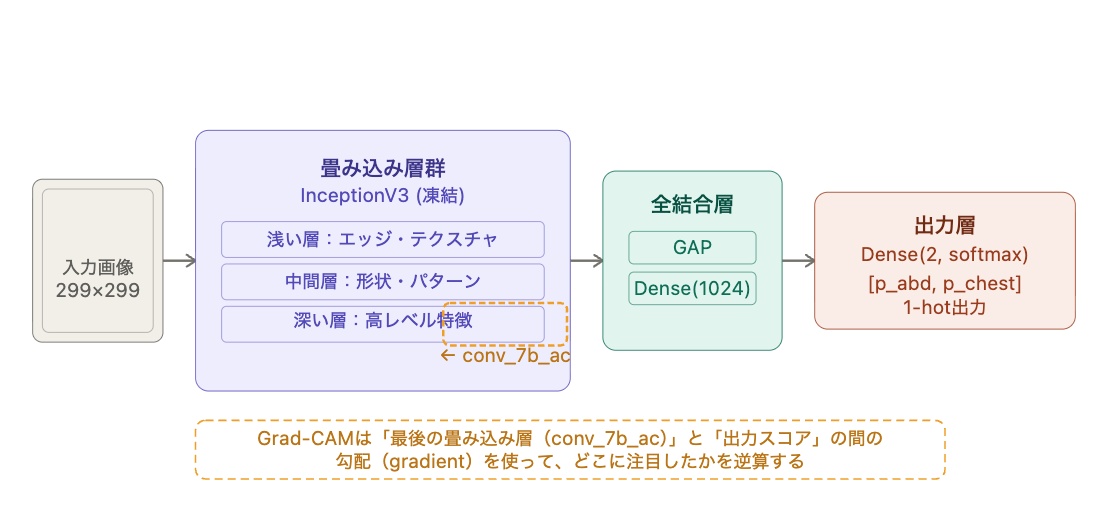

#### Grad-CAMのアルゴリズム

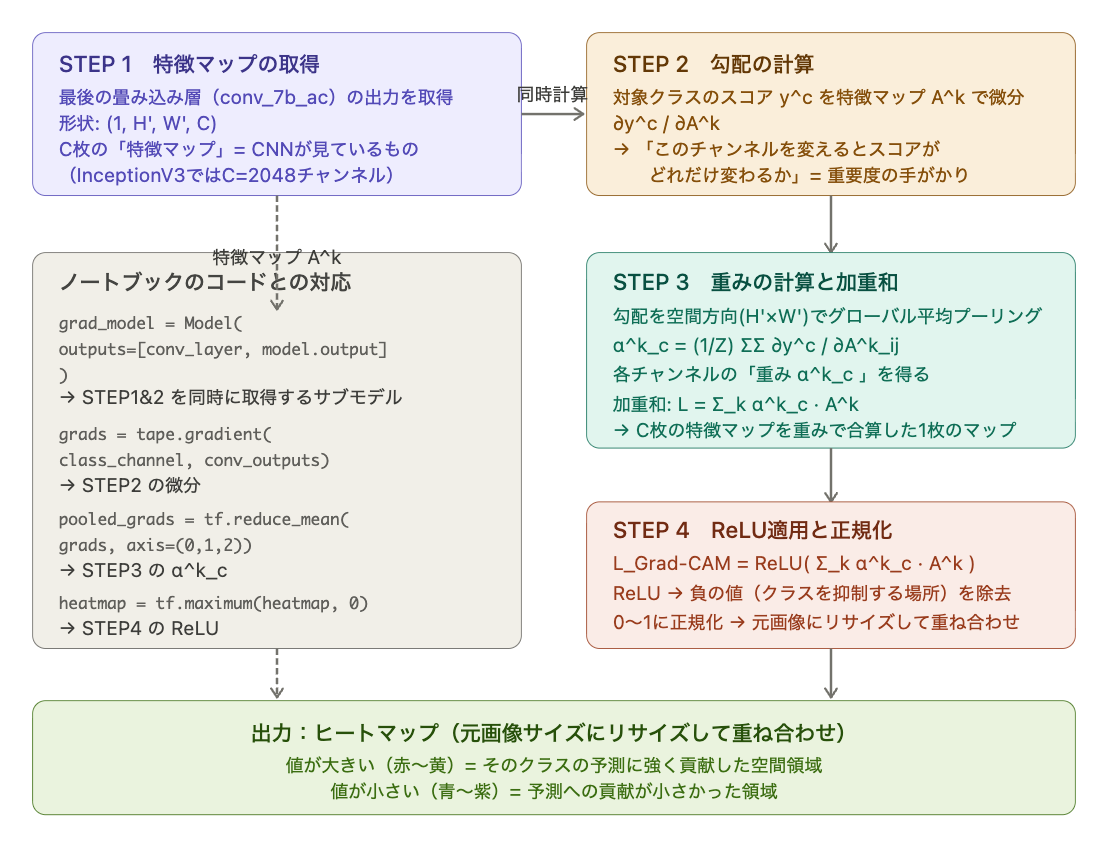

### 4ステップの意味

**STEP 1 — 特徴マップの取得**

最後の畳み込み層（このノートブックでは `conv_7b_ac`）はC=2048チャンネルの特徴マップを出力しています。各チャンネルは「このパターンが画像のどこにあるか」のマップであり、CNNが最終的に使う「見え方」の集合です。

**STEP 2 — 勾配の計算（GradientTape）**

対象クラスのスコア $y^c$ を、その特徴マップ $A^k$ で偏微分します。$\partial y^c / \partial A^k_{ij}$ は「特徴マップのこのピクセル値を少し変えたら、クラススコアがどれだけ変わるか」を意味します。大きければそのチャンネル・その位置が重要ということです。

**STEP 3 — グローバル平均プーリングで重みを得る**

チャンネルごとに、空間全体の勾配を平均して1つのスカラー $\alpha^k_c$ に圧縮します。これが「チャンネル $k$ の重要度」です。全チャンネルの特徴マップをこの重みで加重和すると、1枚の粗いヒートマップ $L$ になります。

**STEP 4 — ReLUで「貢献した領域」だけ残す**

負の値はそのクラスを「抑制」した領域なので、ReLU（ゼロ以下を切り捨て）で除去します。残った正の値だけが「このクラスと判断させた空間領域」です。最後に0〜1に正規化して元画像にリサイズし、カラーマップ（jet）で色付けして重ね合わせます。

### 1-hot形式との関係

このノートブックで1-hot形式にした重要な利点がGrad-CAMにも現れます。binary形式（sigmoid×1ノード）では出力が1つしかなく、「chestとして判断した理由」と「abdとして判断した理由」を分けて可視化できません。一方、softmax×2ノードの1-hot形式では `predictions[:, 0]`（abd）と `predictions[:, 1]`（chest）の勾配を**それぞれ独立して**計算できるため、クラスごとに異なるヒートマップを得ることができます。


#### Grad-CAMの直感的理解

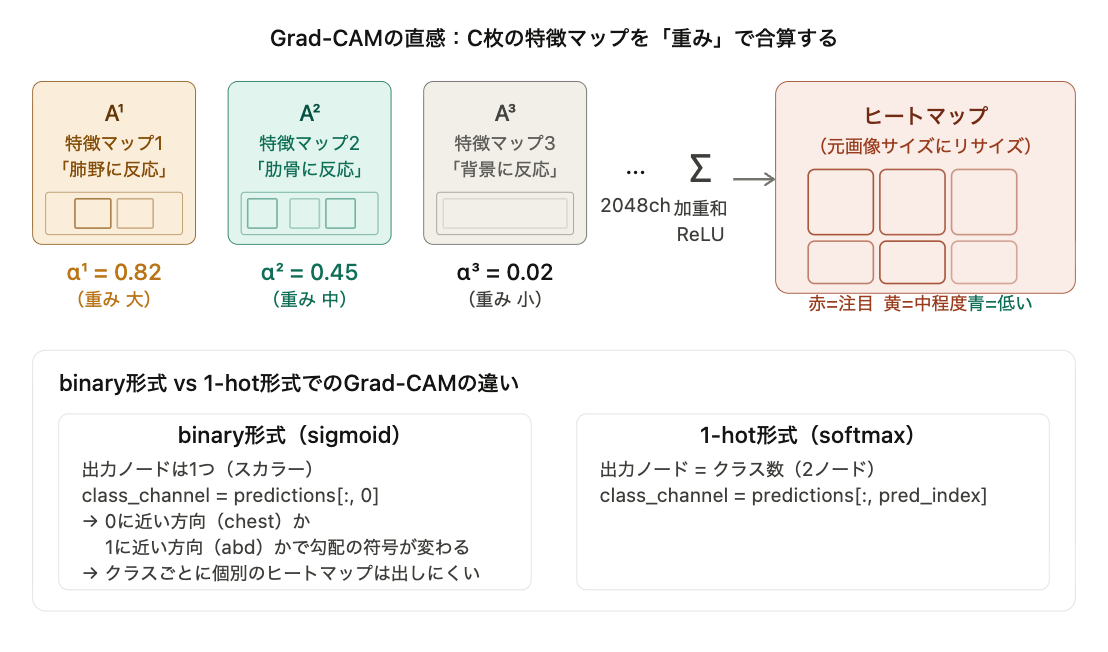

#### 関数定義

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Grad-CAMヒートマップを計算する関数

    Parameters
    ----------
    img_array        : 前処理済み入力画像 (1, H, W, C)
    model            : 学習済みモデル
    last_conv_layer_name : Grad-CAMを計算する畳み込み層の名前
    pred_index       : 対象クラスのインデックス（Noneなら予測クラス）

    Returns
    -------
    heatmap : numpy array (H, W), 値域 [0, 1]
    """
    # 最後の畳み込み層の出力と、モデルの最終出力を取得するサブモデル
    grad_model = Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        # 特徴マップと予測スコアを取得
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            if USE_ONEHOT:
                pred_index = tf.argmax(predictions[0])
            else:
                pred_index = 0  # binary: 単一出力ノード

        # 対象クラスのスコアを取得
        if USE_ONEHOT:
            class_channel = predictions[:, pred_index]
        else:
            class_channel = predictions[:, 0]

    # 特徴マップに対する勾配
    grads = tape.gradient(class_channel, conv_outputs)

    # 各特徴マップの勾配をグローバル平均プーリング → 重みベクトル
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 重みと特徴マップの加重和
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLUで負の値をゼロに（正の寄与のみを見る）
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def display_gradcam(img_path, heatmap, alpha=0.4, title='Grad-CAM'):
    """
    元画像とGrad-CAMヒートマップを重ね合わせて表示する関数

    Parameters
    ----------
    img_path  : 元画像のパス
    heatmap   : make_gradcam_heatmap()の出力
    alpha     : ヒートマップの透明度（0=透明, 1=不透明）
    title     : プロットのタイトル
    """
    # 元画像の読み込み
    img = image.load_img(img_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)

    # ヒートマップをカラーマップに変換（0-255にスケール）
    heatmap_resized = np.uint8(255 * heatmap)
    jet = cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]

    # 元画像サイズにリサイズ
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_array.shape[1], img_array.shape[0]))
    jet_heatmap = image.img_to_array(jet_heatmap)

    # 重ね合わせ
    superimposed_img = jet_heatmap * alpha + img_array
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title('元画像 (Original)', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Grad-CAMヒートマップ', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(superimposed_img)
    axes[2].set_title(f'重ね合わせ (alpha={alpha})', fontsize=12)
    axes[2].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Grad-CAM関数を定義しました')

#### InceptionV3の最終畳み込み層名前を取得

In [ ]:
# InceptionV3の最後の畳み込み層を確認
# Grad-CAMはこの層の特徴マップを使用する

# 畳み込み層の一覧を表示
conv_layers = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
print('畳み込み層（最後の10層）:')
for name in conv_layers[-10:]:
    print(' ', name)

# InceptionV3の最後の畳み込み層
# ※ TensorFlowのバージョンによって層名が異なる
#　 conv_7b_ac（旧名）→ conv2d_93（現環境）
last_conv_layer_name = 'conv2d_93'
print(f'\nGrad-CAMに使用する層: {last_conv_layer_name}')

# 上記の層名が見つからない場合は、以下で動的に取得することもできる
# last_conv_layer_name = conv_layers[-1]
# print(f'動的取得: {last_conv_layer_name}')

### 実際にヒートマップを描出する

In [ ]:
# ============================================================
# Grad-CAMの実行：胸部X線写真
# ============================================================
print('【胸部X線写真のGrad-CAM】')

# 予測クラスのインデックスを取得
if USE_ONEHOT:
    pred_idx_chest = int(np.argmax(score_chest[0]))
    idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
    pred_class_name = idx_to_class[pred_idx_chest]
    print(f'予測クラス: {pred_class_name} (インデックス={pred_idx_chest})')
else:
    pred_idx_chest = 0
    pred_class_name = 'Chest' if score_chest[0][0] < 0.5 else 'Abd'
    print(f'予測クラス: {pred_class_name}')

heatmap_chest = make_gradcam_heatmap(
    x_chest,
    model,
    last_conv_layer_name,
    pred_index=pred_idx_chest
)

display_gradcam(
    img_path,
    heatmap_chest,
    alpha=0.4,
    title=f'Grad-CAM: 胸部X線写真 → 予測: {pred_class_name.upper()}'
)

In [ ]:
# ============================================================
# Grad-CAMの実行：腹部X線写真
# ============================================================
print('【腹部X線写真のGrad-CAM】')

if USE_ONEHOT:
    pred_idx_abd = int(np.argmax(score_abd[0]))
    pred_class_name_abd = idx_to_class[pred_idx_abd]
    print(f'予測クラス: {pred_class_name_abd} (インデックス={pred_idx_abd})')
else:
    pred_idx_abd = 0
    pred_class_name_abd = 'Chest' if score_abd[0][0] < 0.5 else 'Abd'
    print(f'予測クラス: {pred_class_name_abd}')

heatmap_abd = make_gradcam_heatmap(
    x_abd,
    model,
    last_conv_layer_name,
    pred_index=pred_idx_abd
)

display_gradcam(
    img_path2,
    heatmap_abd,
    alpha=0.4,
    title=f'Grad-CAM: 腹部X線写真 → 予測: {pred_class_name_abd.upper()}'
)

### Grad-CAMの読み方

| 色 | 意味 |
|---|---|
| 赤・黄 | モデルが強く注目した領域（高活性化） |
| 青・紫 | モデルがあまり注目していない領域 |

**医学的観点からの検討：**
- 胸部X線において、モデルは肺野・横隔膜ドーム・肋骨などの解剖学的特徴に注目しているか？
- 腹部X線において、骨盤・腰椎・腸管ガスなどに注目しているか？
- 注目領域が解剖学的に妥当でなければ、モデルは画像の本質的な特徴を学習できていない可能性がある

---
# データ拡張をしない場合

データ拡張あり・なしで学習結果を比較する。

In [ ]:
# InceptionV3モデルをベースとして使用（データ拡張なし用）
base_model_na = applications.InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(img_width, img_height, 3))

# 新しい全結合層を追加
x_na = base_model_na.output
x_na = GlobalAveragePooling2D()(x_na)
x_na = Dense(1024, activation='relu')(x_na)
predictions_na = Dense(output_nodes, activation=output_activation)(x_na)

model_non_augmentation = Model(inputs=base_model_na.input, outputs=predictions_na)

for layer in base_model_na.layers:
    layer.trainable = False

model_non_augmentation.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=loss_function,
    metrics=['accuracy'])

print('データ拡張なしモデルを構築しました')

In [ ]:
# 学習（データ拡張なし）
history_non_augmentation = model_non_augmentation.fit(
    train_generator_non_augmentation,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size
)

## 学習過程の表示（データ拡張なし）

In [ ]:
print(history_non_augmentation.history.keys())

plt.figure()
plt.plot(history_non_augmentation.history['accuracy'],     'orange', label='Training accuracy')
plt.plot(history_non_augmentation.history['val_accuracy'], 'blue',   label='Validation accuracy')
plt.plot(history_non_augmentation.history['loss'],         'red',    label='Training loss')
plt.plot(history_non_augmentation.history['val_loss'],     'green',  label='Validation loss')
plt.legend()
plt.show()

## 評価（データ拡張なし）+ Grad-CAM

In [ ]:
# 胸部X線写真の予測（データ拡張なしモデル）
print('=' * 50)
print('【胸部X線写真の予測（データ拡張なし）】')
score_chest_na, x_chest_na = predict_and_display(
    img_path, model_non_augmentation, train_generator.class_indices, USE_ONEHOT)

print('=' * 50)
print('【腹部X線写真の予測（データ拡張なし）】')
score_abd_na, x_abd_na = predict_and_display(
    img_path2, model_non_augmentation, train_generator.class_indices, USE_ONEHOT)

In [ ]:
# Grad-CAM（データ拡張なし）
print('【Grad-CAM: データ拡張なしモデル】')

if USE_ONEHOT:
    pred_idx_c_na = int(np.argmax(score_chest_na[0]))
    pred_idx_a_na = int(np.argmax(score_abd_na[0]))
    pred_name_c_na = idx_to_class[pred_idx_c_na]
    pred_name_a_na = idx_to_class[pred_idx_a_na]
else:
    pred_idx_c_na = 0
    pred_idx_a_na = 0
    pred_name_c_na = 'Chest' if score_chest_na[0][0] < 0.5 else 'Abd'
    pred_name_a_na = 'Chest' if score_abd_na[0][0] < 0.5 else 'Abd'

# データ拡張なしモデルの最終畳み込み層を動的に取得
conv_layers_na = [layer.name for layer in model_non_augmentation.layers if 'conv' in layer.name.lower()]
last_conv_layer_name_na = conv_layers_na[-1]

hm_chest_na = make_gradcam_heatmap(x_chest_na, model_non_augmentation, last_conv_layer_name_na, pred_idx_c_na)
display_gradcam(img_path,  hm_chest_na, title=f'Grad-CAM (拡張なし): 胸部 → {pred_name_c_na.upper()}')

hm_abd_na = make_gradcam_heatmap(x_abd_na, model_non_augmentation, last_conv_layer_name_na, pred_idx_a_na)
display_gradcam(img_path2, hm_abd_na, title=f'Grad-CAM (拡張なし): 腹部 → {pred_name_a_na.upper()}')

---
## 考察：データ拡張あり vs なし

| 比較項目 | データ拡張あり | データ拡張なし |
|---|---|---|
| 訓練精度 | やや低い場合がある | 高い（過学習のリスク） |
| 検証精度 | 一般に高い | 低い場合がある |
| Grad-CAM | 多様な領域に分散 | 特定領域に偏る場合あり |

少数データ（65枚）では過学習が起きやすいため、データ拡張が有効。

Grad-CAMで注目領域を比較することで、モデルの汎化性能を視覚的に評価できる。